# Financial News Sentiment Analysis

This notebook is the cleaned project report and code submission for sentence-level sentiment classification of financial news. It compares a simple embedding average-pooling baseline against a Bidirectional LSTM with attention.


## Metadata

```yaml
project_title: "Financial News Sentiment Analysis with Bi-LSTM and Attention"
dataset_name: "Financial News Sentiment Corpus"
task_type: "Multi-class sentiment classification"
classes:
  - neutral
  - positive
  - negative
primary_metric: "validation accuracy"
models:
  - Embedding average-pooling baseline
  - Bi-LSTM with attention
```


## AI Usage Declaration

| Item | Response |
|---|---|
| Did you use generative AI tools? | Yes  |
| Which tools? | gemini |
| For what purpose? | Code review, structuring, explanations/ coding assist / debugging |
| Which parts were AI-assisted? | Documentation, architecture discussion |
| What did you verify yourself? | All code, experiments, and results |

### Short declaration
Generative AI tools were used to assist with code review, notebook structuring, and documentation clarity. All implementations were executed, tested, and validated independently.


## 1. Problem Definition and Motivation

The goal of this project is to perform **sentence-level sentiment classification** on financial news text. Each sentence is classified as neutral, positive, or negative. This is useful because financial news can influence market perception, investor confidence, and downstream decision-support systems.


## 2. Dataset Description

The dataset contains financial news sentences labeled with sentiment classes. The notebook loads the data directly from a public CSV file, maps sentiment labels to integer classes, and uses a stratified train/validation split so that class proportions remain stable across both sets.


## 3. Setup and Imports


In [28]:
# Core libraries
import random
import copy
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_packed_sequence, pad_sequence, pack_padded_sequence
from torch.utils.data import DataLoader, Dataset


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [30]:
RANDOM_SEED = 42


def set_seed(seed=RANDOM_SEED):
    """Set random seeds so model initialization and shuffling are reproducible."""
    random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
print(f"Random seed: {RANDOM_SEED}")


Random seed: 42


## 4. Data Loading


In [31]:
DATA_URL = "https://raw.githubusercontent.com/ukairia777/finance_sentiment_corpus/main/finance_data.csv"

df = pd.read_csv(DATA_URL)

print(df.head())
print(f"Total samples: {len(df)}")


     labels                                           sentence  \
0   neutral  According to Gran, the company has no plans to...   
1   neutral  Technopolis plans to develop in stages an area...   
2  negative  The international electronic industry company ...   
3  positive  With the new production plant the company woul...   
4  positive  According to the company's updated strategy fo...   

                                        kor_sentence  
0  Gran에 따르면, 그 회사는 회사가 성장하고 있는 곳이지만, 모든 생산을 러시아로...  
1  테크노폴리스는 컴퓨터 기술과 통신 분야에서 일하는 회사들을 유치하기 위해 10만 평...  
2  국제 전자산업 회사인 엘코텍은 탈린 공장에서 수십 명의 직원을 해고했으며, 이전의 ...  
3  새로운 생산공장으로 인해 회사는 예상되는 수요 증가를 충족시킬 수 있는 능력을 증가...  
4  2009-2012년 회사의 업데이트된 전략에 따르면, Basware는 20% - 4...  
Total samples: 4846


## 5. Label Preprocessing


In [32]:
LABEL_MAPPING = {
    "neutral": 0,
    "positive": 1,
    "negative": 2,
}

NUM_CLASSES = len(LABEL_MAPPING)

df["labels"] = df["labels"].map(LABEL_MAPPING)
df = df.dropna().reset_index(drop=True)

print(df["labels"].value_counts())


labels
0    2879
1    1363
2     604
Name: count, dtype: int64


## 6. Tokenization and Vocabulary


In [33]:
def tokenize(text: str):
    """Lowercase and tokenize text using a simple regex tokenizer."""
    text = text.lower()
    # Using a raw string with proper word boundaries
    return re.findall(r"\b\w+\b", text)


def build_vocab(sentences, min_freq=1):
    """Build a token vocabulary from the training sentences."""
    counter = Counter()
    for sentence in sentences:
        counter.update(tokenize(sentence))

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


def encode_text(text, vocab):
    """Convert a sentence to token IDs."""
    return [vocab.get(token, vocab["<UNK>"]) for token in tokenize(text)]

## 7. Dataset and DataLoaders


In [34]:
class FinancialNewsDataset(Dataset):
    """PyTorch dataset for financial news sentiment examples."""

    def __init__(self, dataframe, vocab):
        self.sentences = dataframe["sentence"].tolist()
        self.labels = dataframe["labels"].tolist()
        self.vocab = vocab

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        token_ids = encode_text(self.sentences[idx], self.vocab)
        label = self.labels[idx]

        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(label, dtype=torch.long),
        )


def collate_fn(batch):
    """Pad variable-length token sequences in a batch."""
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(text) for text in texts], dtype=torch.long)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return texts_padded, lengths, labels


In [35]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["labels"],
    random_state=42,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

vocab = build_vocab(train_df["sentence"].tolist())
pad_idx = vocab["<PAD>"]

counts = train_df["labels"].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
class_weights = torch.tensor(weights, dtype=torch.float)

print("Class counts:", counts)
print("Class weights:", class_weights)


Class counts: [2303 1090  483]
Class weights: tensor([0.3807, 0.8043, 1.8151])


In [36]:
BATCH_SIZE = 32

train_dataset = FinancialNewsDataset(train_df, vocab)
val_dataset = FinancialNewsDataset(val_df, vocab)

train_generator = torch.Generator()
train_generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    generator=train_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)


## 8. Shared Training and Evaluation Utilities


In [37]:
def get_logits(model_output):
    """Return logits from models that may also return attention weights."""
    if isinstance(model_output, tuple):
        return model_output[0]
    return model_output


def train_one_epoch(model, dataloader, criterion, optimizer, device, max_grad_norm=1.0):
    """Train a model for one epoch."""
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_texts, batch_lengths, batch_labels in dataloader:
        batch_texts = batch_texts.to(device)
        batch_lengths = batch_lengths.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = get_logits(model(batch_texts, batch_lengths))
        loss = criterion(logits, batch_labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        optimizer.step()

        batch_size = batch_labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


In [38]:
def evaluate(model, dataloader, criterion, device):
    """Evaluate a model on a validation dataloader."""
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch_texts, batch_lengths, batch_labels in dataloader:
            batch_texts = batch_texts.to(device)
            batch_lengths = batch_lengths.to(device)
            batch_labels = batch_labels.to(device)

            logits = get_logits(model(batch_texts, batch_lengths))
            loss = criterion(logits, batch_labels)

            batch_size = batch_labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


In [39]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    scheduler=None,
    early_stopping_patience=3,
    max_grad_norm=1.0,
):
    """Train a model with validation tracking and early stopping."""
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            max_grad_norm=max_grad_norm,
        )

        val_loss, val_acc = evaluate(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if scheduler is not None:
            scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"LR: {current_lr:.6f} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        if epochs_without_improvement >= early_stopping_patience:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\nBest Validation Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")

    return history


In [40]:
def make_plateau_scheduler(optimizer):
    """Create the ReduceLROnPlateau scheduler used by both models."""
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
    )


## 9. Baseline Model

The baseline ignores word order and classifies each sentence from the masked average of its token embeddings. It provides a simple comparison point for the proposed sequence model.


In [41]:
class EmbeddingAvgPoolClassifier(nn.Module):
    """Baseline classifier using masked average pooling of embeddings."""

    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0, dropout=0.3):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, lengths=None):
        embeddings = self.embedding(input_ids)
        mask = (input_ids != self.pad_idx).unsqueeze(-1)
        pooled = (embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-8)
        return self.fc(self.dropout(pooled))


In [42]:
def build_fresh_baseline(
    vocab,
    class_weights,
    pad_idx,
    device,
    embed_dim=100,
    dropout=0.3,
    lr=1e-3,
    weight_decay=0.0,
):
    """Create a fresh baseline model, loss function, and optimizer."""
    model = EmbeddingAvgPoolClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        num_classes=NUM_CLASSES,
        pad_idx=pad_idx,
        dropout=dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    return model, criterion, optimizer


### Training the Baseline Model


In [43]:
set_seed(RANDOM_SEED)

baseline_model, criterion_base, optimizer_base = build_fresh_baseline(
    vocab=vocab,
    pad_idx=pad_idx,
    class_weights=class_weights,
    device=device,
    embed_dim=100,
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-5,
)

scheduler_base = make_plateau_scheduler(optimizer_base)

history_baseline = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_base,
    optimizer=optimizer_base,
    device=device,
    epochs=30,
    scheduler=scheduler_base,
    early_stopping_patience=3,
    max_grad_norm=1.0,
)


Epoch [1/30] | LR: 0.001000 | Train Loss: 1.0697, Train Acc: 0.4592 | Val Loss: 1.0420, Val Acc: 0.4990
Epoch [2/30] | LR: 0.001000 | Train Loss: 1.0159, Train Acc: 0.5459 | Val Loss: 1.0002, Val Acc: 0.5588
Epoch [3/30] | LR: 0.001000 | Train Loss: 0.9659, Train Acc: 0.5980 | Val Loss: 0.9627, Val Acc: 0.5825
Epoch [4/30] | LR: 0.001000 | Train Loss: 0.9154, Train Acc: 0.6331 | Val Loss: 0.9292, Val Acc: 0.6082
Epoch [5/30] | LR: 0.001000 | Train Loss: 0.8660, Train Acc: 0.6535 | Val Loss: 0.8961, Val Acc: 0.6268
Epoch [6/30] | LR: 0.001000 | Train Loss: 0.8059, Train Acc: 0.6783 | Val Loss: 0.8662, Val Acc: 0.6258
Epoch [7/30] | LR: 0.001000 | Train Loss: 0.7488, Train Acc: 0.7178 | Val Loss: 0.8374, Val Acc: 0.6474
Epoch [8/30] | LR: 0.001000 | Train Loss: 0.6973, Train Acc: 0.7441 | Val Loss: 0.8113, Val Acc: 0.6649
Epoch [9/30] | LR: 0.001000 | Train Loss: 0.6473, Train Acc: 0.7580 | Val Loss: 0.7869, Val Acc: 0.6835
Epoch [10/30] | LR: 0.001000 | Train Loss: 0.6000, Train Acc: 0.

## 10. Bi-LSTM with Attention

The proposed model uses a Bidirectional LSTM to encode each sentence and an attention layer to weight token representations before classification.


In [44]:
class BiLSTMAttentionClassifier(nn.Module):
    """Bidirectional LSTM with attention for sentence classification."""

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        pad_idx=0,
        num_layers=1,
        dropout=0.3,
    ):
        super().__init__()
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx,
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, lengths=None):
        embeddings = self.embedding(input_ids)

        if lengths is not None:
            packed_embeddings = pack_padded_sequence(
                embeddings,
                lengths.cpu(),
                batch_first=True,
                enforce_sorted=False,
            )
            packed_out, _ = self.lstm(packed_embeddings)
            lstm_out, _ = pad_packed_sequence(
                packed_out,
                batch_first=True,
                total_length=input_ids.size(1),
            )
        else:
            lstm_out, _ = self.lstm(embeddings)

        mask = input_ids != self.pad_idx
        attention_scores = self.attention(lstm_out).squeeze(-1)
        attention_scores = attention_scores.masked_fill(~mask, -1e9)
        attention_weights = F.softmax(attention_scores, dim=1)

        context = torch.bmm(attention_weights.unsqueeze(1), lstm_out).squeeze(1)
        logits = self.fc(self.dropout(context))

        return logits, attention_weights


In [45]:
def build_fresh_attn_model(
    vocab,
    pad_idx,
    class_weights,
    device,
    embed_dim=100,
    hidden_dim=98,
    dropout=0.3,
    lr=1e-3,
    weight_decay=0.0,
):
    """Create a fresh Bi-LSTM attention model, loss function, and optimizer."""
    model = BiLSTMAttentionClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_classes=NUM_CLASSES,
        pad_idx=pad_idx,
        dropout=dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    return model, criterion, optimizer


In [46]:
set_seed(RANDOM_SEED)

attn_model, criterion_attn, optimizer_attn = build_fresh_attn_model(
    vocab=vocab,
    pad_idx=pad_idx,
    class_weights=class_weights,
    device=device,
    embed_dim=100,
    hidden_dim=98,
    dropout=0.5,
    lr=1e-3,
    weight_decay=1e-5,
)


### Attention Forward-Pass Check


In [47]:
batch_texts, batch_lengths, batch_labels = next(iter(train_loader))
batch_texts = batch_texts.to(device)
batch_lengths = batch_lengths.to(device)
batch_labels = batch_labels.to(device)

logits, attention_weights = attn_model(batch_texts, batch_lengths)

print("Input shape:", batch_texts.shape)
print("Logits shape:", logits.shape)
print("Attention weights shape:", attention_weights.shape)
print("Attention row sums (first 5):", attention_weights.sum(dim=1)[:5])


Input shape: torch.Size([32, 41])
Logits shape: torch.Size([32, 3])
Attention weights shape: torch.Size([32, 41])
Attention row sums (first 5): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)


In [48]:
assert logits.shape == (batch_texts.size(0), NUM_CLASSES)
assert attention_weights.shape == batch_texts.shape

row_sums = attention_weights.sum(dim=1)
ones = torch.ones_like(row_sums)
assert torch.allclose(row_sums, ones, atol=1e-4), "Attention weights do not sum to 1."

print("Forward pass is correct.")


Forward pass is correct.


### Training the Bi-LSTM Attention Model


In [49]:
scheduler_attn = make_plateau_scheduler(optimizer_attn)

history_attn = train_model(
    model=attn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_attn,
    optimizer=optimizer_attn,
    device=device,
    epochs=30,
    scheduler=scheduler_attn,
    early_stopping_patience=3,
    max_grad_norm=1.0,
)


Epoch [1/30] | LR: 0.001000 | Train Loss: 1.0092, Train Acc: 0.4819 | Val Loss: 0.9155, Val Acc: 0.5948
Epoch [2/30] | LR: 0.001000 | Train Loss: 0.7784, Train Acc: 0.6664 | Val Loss: 0.8536, Val Acc: 0.6546
Epoch [3/30] | LR: 0.001000 | Train Loss: 0.5878, Train Acc: 0.7562 | Val Loss: 0.7974, Val Acc: 0.7000
Epoch [4/30] | LR: 0.001000 | Train Loss: 0.4361, Train Acc: 0.8173 | Val Loss: 0.8047, Val Acc: 0.7206
Epoch [5/30] | LR: 0.001000 | Train Loss: 0.3009, Train Acc: 0.8700 | Val Loss: 0.9626, Val Acc: 0.7247
Epoch [6/30] | LR: 0.001000 | Train Loss: 0.1997, Train Acc: 0.9177 | Val Loss: 1.1175, Val Acc: 0.7041
Epoch [7/30] | LR: 0.001000 | Train Loss: 0.1277, Train Acc: 0.9512 | Val Loss: 1.2781, Val Acc: 0.7268
Epoch [8/30] | LR: 0.001000 | Train Loss: 0.0866, Train Acc: 0.9698 | Val Loss: 1.6364, Val Acc: 0.7402
Epoch [9/30] | LR: 0.001000 | Train Loss: 0.0602, Train Acc: 0.9799 | Val Loss: 1.6758, Val Acc: 0.7392
Epoch [10/30] | LR: 0.000500 | Train Loss: 0.0399, Train Acc: 0.

## 11. Training Curves and Model Comparison


In [50]:
def plot_training_curves(history, model_name="Model"):
    """Plot training and validation loss/accuracy curves."""
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


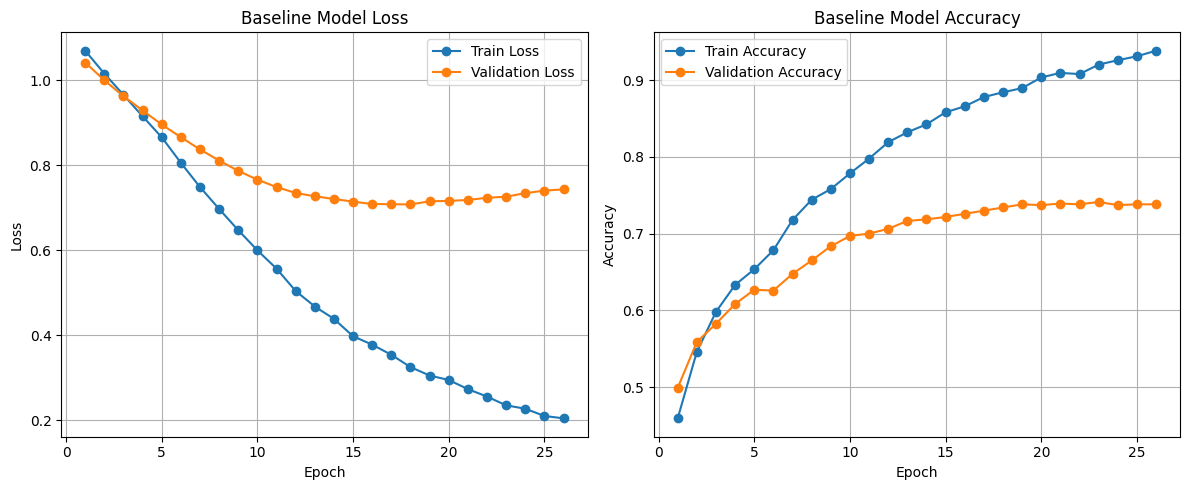

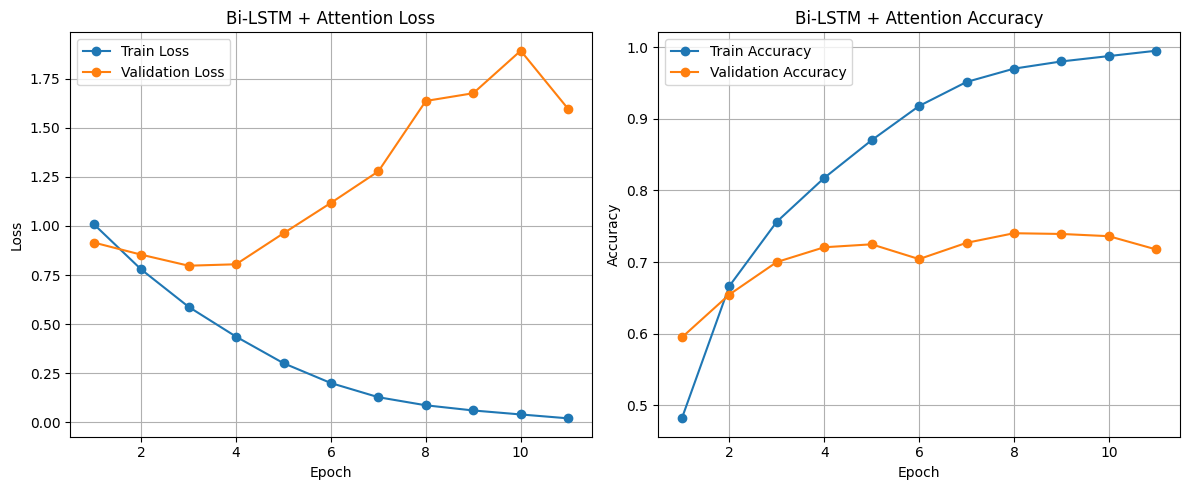

In [51]:
plot_training_curves(history_baseline, model_name="Baseline Model")
plot_training_curves(history_attn, model_name="Bi-LSTM + Attention")


In [52]:
best_baseline_val_acc = max(history_baseline["val_acc"])
best_attn_val_acc = max(history_attn["val_acc"])

print(f"Best Baseline Validation Accuracy: {best_baseline_val_acc:.4f}")
print(f"Best Bi-LSTM + Attention Validation Accuracy: {best_attn_val_acc:.4f}")


Best Baseline Validation Accuracy: 0.7412
Best Bi-LSTM + Attention Validation Accuracy: 0.7402


In [53]:
def plot_model_comparison(history_a, history_b, name_a="Baseline", name_b="Bi-LSTM + Attention"):
    """Plot validation curves for two models on the same figure."""
    epochs_a = range(1, len(history_a["val_acc"]) + 1)
    epochs_b = range(1, len(history_b["val_acc"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_a, history_a["val_loss"], marker="o", label=f"{name_a} Val Loss")
    plt.plot(epochs_b, history_b["val_loss"], marker="o", label=f"{name_b} Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_a, history_a["val_acc"], marker="o", label=f"{name_a} Val Accuracy")
    plt.plot(epochs_b, history_b["val_acc"], marker="o", label=f"{name_b} Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


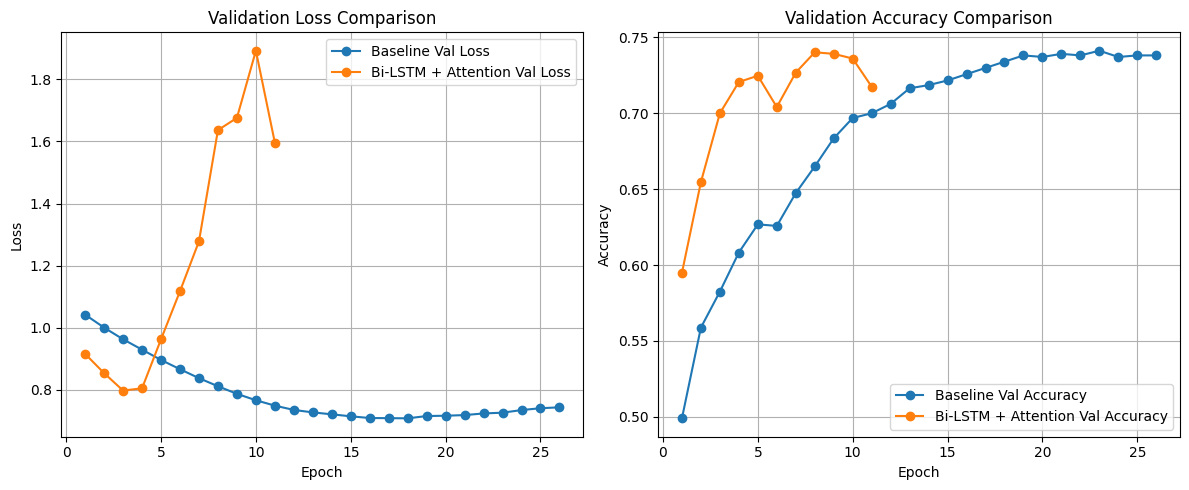

In [54]:
plot_model_comparison(
    history_baseline,
    history_attn,
    name_a="Baseline",
    name_b="Bi-LSTM + Attention",
)


## 12. Evaluation Methodology

The models are evaluated using a stratified train/validation split. Validation accuracy is the main metric because the task is multi-class classification and the notebook compares both models on the same held-out validation set.

## 13. Experimental Results

After training both models, compare the best validation accuracy values and the validation curves. The Bi-LSTM with attention is expected to capture word order and contextual patterns that the average-pooling baseline cannot model.

## 14. Discussion and Interpretation

The baseline provides a useful reference point because it is simple and fast. The Bi-LSTM with attention is more expressive, but it also has more parameters and may be more sensitive to hyperparameters, regularization, and training time.

## 15. Limitations and Fairness

This experiment uses a single train/validation split and a relatively small financial-news dataset. Results may vary with different splits, larger datasets, pretrained embeddings, or transformer-based models. The dataset labels and news sources may also reflect financial-domain and annotation biases.

## 16. Reproducibility

The notebook uses a fixed `random_state=42` for the train/validation split. For stronger reproducibility, future versions could also set PyTorch random seeds and document package versions.

## 17. Final Conclusion

This notebook demonstrates a complete workflow for financial news sentiment classification, from preprocessing through baseline comparison and Bi-LSTM attention modeling.

## 18. Self-Evaluation

The cleaned notebook is organized to support rerunning the full experiment from top to bottom while keeping model code, training utilities, and result visualization easy to inspect.
